In [1]:
import tensorflow as tf
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np
import matplotlib.pyplot as plt
import os

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

2026-04-19 16:47:46.848863: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


TensorFlow version: 2.15.0
GPU available: []


In [19]:
import os
import shutil
import random
from sklearn.model_selection import train_test_split

SOURCE_DIR = "dataset"
NEW_TRAIN_DIR = "dataset_fixed/train"
NEW_TEST_DIR = "dataset_fixed/test"
SPLIT_RATIO = 0.2  # 80% train, 20% test
random.seed(42)

for class_name in CLASS_NAMES:
    # collect all images from both train and test
    all_images = []
    
    for split in ['train', 'test']:
        class_path = os.path.join(SOURCE_DIR, split, class_name)
        if os.path.exists(class_path):
            for img in os.listdir(class_path):
                if img.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp')):
                    all_images.append(os.path.join(class_path, img))
    
    # split properly
    train_imgs, test_imgs = train_test_split(
        all_images, test_size=SPLIT_RATIO, random_state=42
    )
    
    # copy to new folders
    for img_path in train_imgs:
        dst = os.path.join(NEW_TRAIN_DIR, class_name)
        os.makedirs(dst, exist_ok=True)
        shutil.copy(img_path, dst)
    
    for img_path in test_imgs:
        dst = os.path.join(NEW_TEST_DIR, class_name)
        os.makedirs(dst, exist_ok=True)
        shutil.copy(img_path, dst)

print("New TRAIN set:")
for cls in CLASS_NAMES:
    count = len(os.listdir(os.path.join(NEW_TRAIN_DIR, cls)))
    print(f"  {cls}: {count} images")

print("\nNew TEST set:")
for cls in CLASS_NAMES:
    count = len(os.listdir(os.path.join(NEW_TEST_DIR, cls)))
    print(f"  {cls}: {count} images")

New TRAIN set:
  Acral_Lentiginous_Melanoma: 509 images
  clubbing: 534 images
  healthy: 248 images
  psoriasis: 343 images

New TEST set:
  Acral_Lentiginous_Melanoma: 128 images
  clubbing: 134 images
  healthy: 62 images
  psoriasis: 86 images


In [39]:
TRAIN_DIR = "dataset_fixed/train"
TEST_DIR  = "dataset_fixed/test"

IMG_SIZE   = 224
BATCH_SIZE = 32
EPOCHS     = 15

CLASS_NAMES = sorted([c for c in os.listdir(TRAIN_DIR) if not c.startswith('.')])
NUM_CLASSES = len(CLASS_NAMES)

print("Classes found:", CLASS_NAMES)
print("Number of classes:", NUM_CLASSES)

Classes found: ['Acral_Lentiginous_Melanoma', 'clubbing', 'healthy', 'psoriasis']
Number of classes: 4


In [40]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

train_data = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    classes=CLASS_NAMES,
    color_mode='rgb'
)

test_data = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    classes=CLASS_NAMES,
    color_mode='rgb'
)

# verify pixel values
images, labels = next(test_data)
print("Pixel min:", np.min(images[0]))
print("Pixel max:", np.max(images[0]))
print("Pixel mean:", np.mean(images[0]))
print("Train samples:", train_data.samples)
print("Test samples:", test_data.samples)

Found 1634 images belonging to 4 classes.
Found 410 images belonging to 4 classes.
Pixel min: 36.0
Pixel max: 255.0
Pixel mean: 193.31508
Train samples: 1634
Test samples: 410


In [41]:
train_counts = {}
for class_name in CLASS_NAMES:
    class_path = os.path.join(TRAIN_DIR, class_name)
    train_counts[class_name] = len([
        f for f in os.listdir(class_path)
        if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp'))
    ])

print("Train counts:", train_counts)

total = sum(train_counts.values())
class_weights = {
    i: total / (NUM_CLASSES * train_counts[cls])
    for i, cls in enumerate(CLASS_NAMES)
}

print("Class weights:", class_weights)

Train counts: {'Acral_Lentiginous_Melanoma': 509, 'clubbing': 534, 'healthy': 248, 'psoriasis': 343}
Class weights: {0: 0.8025540275049116, 1: 0.7649812734082397, 2: 1.6471774193548387, 3: 1.1909620991253644}


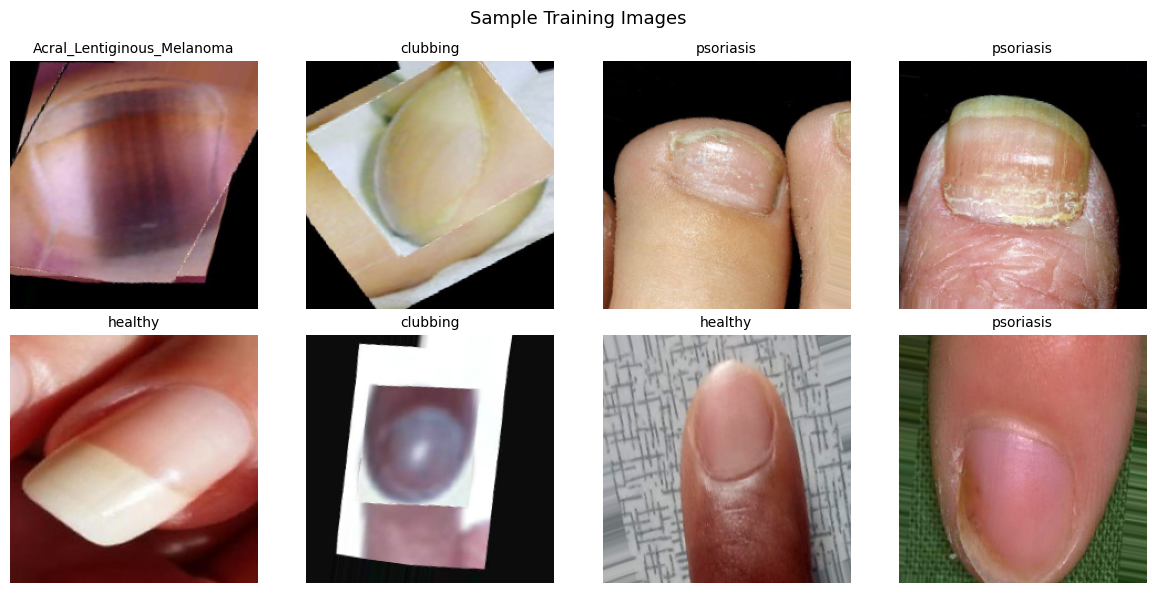

In [43]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras import layers, models, Input
from tensorflow.keras.optimizers import Adam


fig, axes = plt.subplots(2, 4, figsize=(12, 6))
axes = axes.flatten()

images, labels = next(train_data)

for i in range(8):
    img = images[i]
    img = (img - img.min()) / (img.max() - img.min())  # normalize for display only
    axes[i].imshow(img)
    class_idx = np.argmax(labels[i])
    axes[i].set_title(CLASS_NAMES[class_idx], fontsize=10)
    axes[i].axis('off')

plt.suptitle("Sample Training Images", fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
base_model = EfficientNetB0(
    weights='imagenet',
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

base_model.trainable = False

inputs = Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)

model = models.Model(inputs, outputs)

model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Model ready!")
model.summary()

Phase 1 training (frozen base):

In [44]:
history_phase1 = model.fit(
    train_data,
    epochs=15,
    validation_data=test_data,
    class_weight=class_weights,
    callbacks=[
        EarlyStopping(monitor='val_accuracy', patience=4, restore_best_weights=True, verbose=1),
        ModelCheckpoint("model/nail_model.keras", monitor='val_accuracy', save_best_only=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=2, min_lr=1e-7, verbose=1)
    ]
)
print("Phase 1 complete!")

Epoch 1/15
52/52 [==============================] - ETA: 0s - loss: 0.0994 - accuracy: 0.9584
Epoch 1: val_accuracy improved from -inf to 0.95610, saving model to model/nail_model.keras
52/52 [==============================] - 72s 1s/step - loss: 0.0994 - accuracy: 0.9584 - val_loss: 0.1232 - val_accuracy: 0.9561 - lr: 0.0010
Epoch 2/15
52/52 [==============================] - ETA: 0s - loss: 0.0665 - accuracy: 0.9670
Epoch 2: val_accuracy improved from 0.95610 to 0.95854, saving model to model/nail_model.keras
52/52 [==============================] - 65s 1s/step - loss: 0.0665 - accuracy: 0.9670 - val_loss: 0.1014 - val_accuracy: 0.9585 - lr: 0.0010
Epoch 3/15
52/52 [==============================] - ETA: 0s - loss: 0.0676 - accuracy: 0.9712
Epoch 3: val_accuracy improved from 0.95854 to 0.96341, saving model to model/nail_model.keras
52/52 [==============================] - 66s 1s/step - loss: 0.0676 - accuracy: 0.9712 - val_loss: 0.1034 - val_accuracy: 0.9634 - lr: 0.0010
Epoch 4/15

Phase 2 fine-tuning (unfreeze top 20 layers):

In [45]:
base_model.trainable = True
for layer in base_model.layers[:-20]:
    layer.trainable = False

model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Phase 2 — fine-tuning top 20 layers")

history_phase2 = model.fit(
    train_data,
    epochs=20,
    validation_data=test_data,
    class_weight=class_weights,
    callbacks=[
        EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True, verbose=1),
        ModelCheckpoint("model/nail_model.keras", monitor='val_accuracy', save_best_only=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=2, min_lr=1e-7, verbose=1)
    ]
)
print("Phase 2 complete!")

Phase 2 — fine-tuning top 20 layers
Epoch 1/20
52/52 [==============================] - ETA: 0s - loss: 0.0539 - accuracy: 0.9780
Epoch 1: val_accuracy improved from -inf to 0.97073, saving model to model/nail_model.keras
52/52 [==============================] - 94s 2s/step - loss: 0.0539 - accuracy: 0.9780 - val_loss: 0.0959 - val_accuracy: 0.9707 - lr: 1.0000e-05
Epoch 2/20
52/52 [==============================] - ETA: 0s - loss: 0.0606 - accuracy: 0.9767
Epoch 2: val_accuracy did not improve from 0.97073
52/52 [==============================] - 77s 1s/step - loss: 0.0606 - accuracy: 0.9767 - val_loss: 0.0973 - val_accuracy: 0.9683 - lr: 1.0000e-05
Epoch 3/20
52/52 [==============================] - ETA: 0s - loss: 0.0519 - accuracy: 0.9774
Epoch 3: val_accuracy did not improve from 0.97073

Epoch 3: ReduceLROnPlateau reducing learning rate to 2.9999999242136253e-06.
52/52 [==============================] - 74s 1s/step - loss: 0.0519 - accuracy: 0.9774 - val_loss: 0.0959 - val_accura

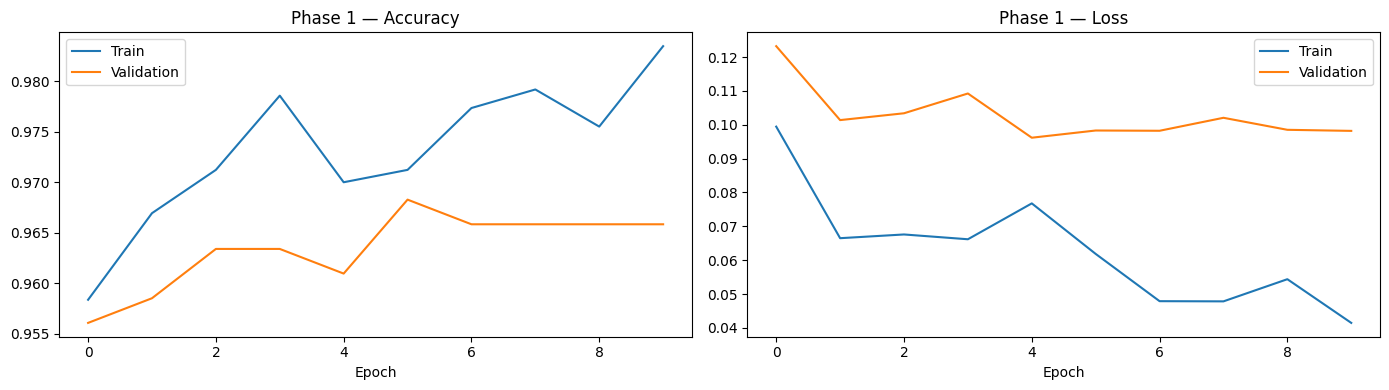

13/13 [==============================] - 15s 1s/step - loss: 0.0959 - accuracy: 0.9707

Final Test Accuracy: 97.07%
Final Test Loss: 0.0959


In [46]:
# plot phase 1
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(history_phase1.history['accuracy'], label='Train')
axes[0].plot(history_phase1.history['val_accuracy'], label='Validation')
axes[0].set_title('Phase 1 — Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(history_phase1.history['loss'], label='Train')
axes[1].plot(history_phase1.history['val_loss'], label='Validation')
axes[1].set_title('Phase 1 — Loss')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.tight_layout()
plt.show()

# final evaluation
loss, accuracy = model.evaluate(test_data, verbose=1)
print(f"\nFinal Test Accuracy: {round(accuracy * 100, 2)}%")
print(f"Final Test Loss: {round(loss, 4)}")

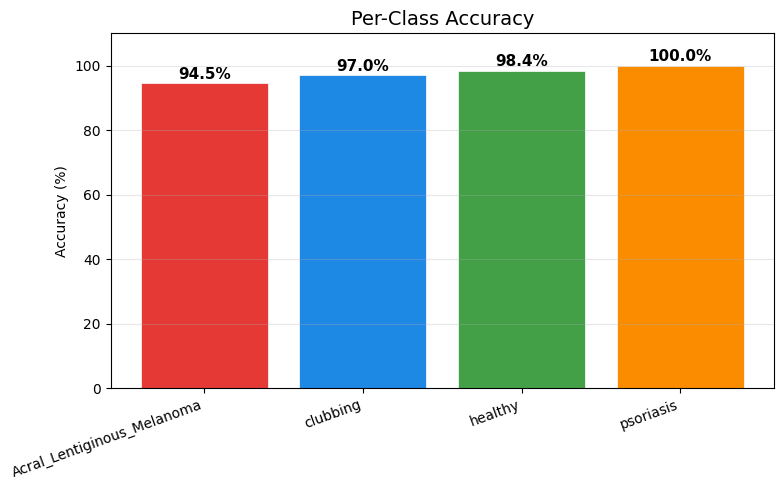

In [52]:
# per class accuracy from confusion matrix
per_class_acc = cm.diagonal() / cm.sum(axis=1)
colors = ['#E53935', '#1E88E5', '#43A047', '#FB8C00']

plt.figure(figsize=(8, 5))
bars = plt.bar(CLASS_NAMES, per_class_acc * 100, color=colors, edgecolor='white', linewidth=0.5)

for bar, acc in zip(bars, per_class_acc):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.5,
             f'{acc*100:.1f}%',
             ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.title('Per-Class Accuracy', fontsize=14)
plt.ylabel('Accuracy (%)')
plt.ylim(0, 110)
plt.xticks(rotation=20, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('plots/per_class_accuracy.png', dpi=300, bbox_inches='tight')
plt.show()

Found 410 images belonging to 4 classes.
13/13 [==============================] - 13s 992ms/step
Unique predicted classes: [0 1 2 3]
Unique true classes: [0 1 2 3]
Total predictions: 410
Total true labels: 410
                            precision    recall  f1-score   support

Acral_Lentiginous_Melanoma       0.97      0.95      0.96       128
                  clubbing       0.95      0.97      0.96       134
                   healthy       1.00      0.98      0.99        62
                 psoriasis       0.99      1.00      0.99        86

                  accuracy                           0.97       410
                 macro avg       0.98      0.97      0.98       410
              weighted avg       0.97      0.97      0.97       410



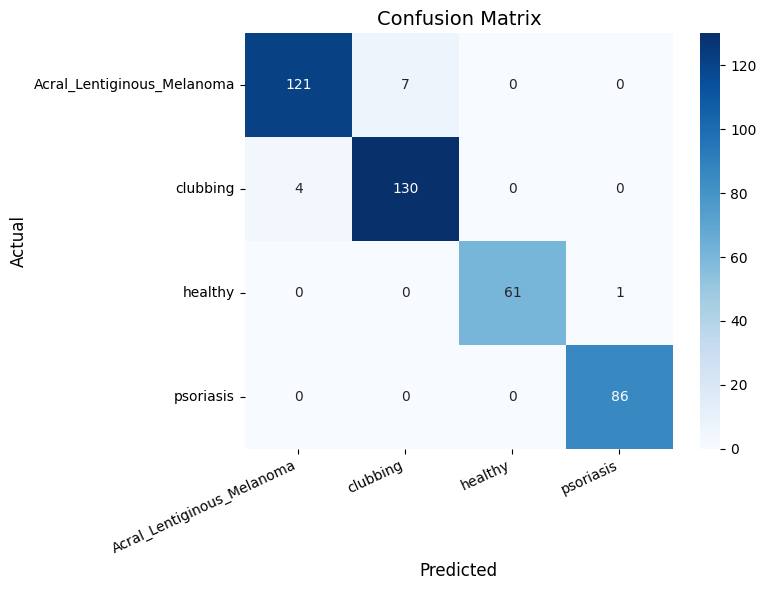

In [51]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

os.makedirs("plots", exist_ok=True)

# create a fresh test generator with NO shuffle
test_datagen_eval = ImageDataGenerator(preprocessing_function=preprocess_input)

test_data_eval = test_datagen_eval.flow_from_directory(
    TEST_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    classes=CLASS_NAMES,
    color_mode='rgb',
    shuffle=False       # ← critical fix
)

# get predictions
y_pred = model.predict(test_data_eval, verbose=1)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = test_data_eval.classes

print("Unique predicted classes:", np.unique(y_pred_classes))
print("Unique true classes:", np.unique(y_true))
print("Total predictions:", len(y_pred_classes))
print("Total true labels:", len(y_true))

# classification report
report = classification_report(y_true, y_pred_classes, target_names=CLASS_NAMES)
print(report)

# confusion matrix
cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES,
            yticklabels=CLASS_NAMES)
plt.title('Confusion Matrix', fontsize=14)
plt.ylabel('Actual', fontsize=12)
plt.xlabel('Predicted', fontsize=12)
plt.xticks(rotation=25, ha='right')
plt.tight_layout()
plt.savefig('plots/confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

In [53]:
print(os.path.exists("model/nail_model.keras"))  # should print True
print(os.path.getsize("model/nail_model.keras") / 1024 / 1024, "MB")

True
30.29865264892578 MB
